# 📊 쇼핑몰 매출 분석 실습 (한글 버전)

## STEP 1. 데이터 불러오기
`dirty_data_kor.csv` 파일을 불러오세요

In [17]:
import pandas as pd
import numpy as np
df = pd.read_csv('./dirty_data_kor.csv')
df

,주문ID,고객명,주문일자,카테고리,상품명,주문수량,개당가격,주문금액,도시,국가,결제방식
0,ORD-1001,김민수,2026-04-01,전자,마우스,2,15000,30000.0,서울,한국,카드
1,ORD-1002,이서연,2026-04-01,생활,스탠드,1,22000,22000.0,부산,한국,카드
2,ORD-1003,박지훈,2026-04-02,전자,케이블,3,5000,15000.0,서울,한국,현금
3,ORD-1004,최유진,2026-04-02,주방,물병,2,12000,24000.0,인천,한국,NaN
4,ORD-1005,정하늘,2026-04-03,생활,노트북거치대,1,28000,28000.0,대구,한국,계좌이체
5,ORD-1006,한지민,2026-04-03,전자,마우스,1,15000,15000.0,서울,한국,카드
6,ORD-1007,오준호,2026-04-04,주방,머그컵,4,7000,NaN,부산,한국,현금
7,ORD-1008,강소라,2026-04-04,생활,스탠드,2,22000,44000.0,서울,한국,카드


## STEP 2. 데이터 구조 확인

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   주문ID    8 non-null      object 
 1   고객명     8 non-null      object 
 2   주문일자    8 non-null      object 
 3   카테고리    8 non-null      object 
 4   상품명     8 non-null      object 
 5   주문수량    8 non-null      int64  
 6   개당가격    8 non-null      int64  
 7   주문금액    7 non-null      float64
 8   도시      8 non-null      object 
 9   국가      8 non-null      object 
 10  결제방식    7 non-null      object 
dtypes: float64(1), int64(2), object(8)
memory usage: 836.0+ bytes


In [3]:
df.describe()

,주문수량,개당가격,주문금액
count,8.000000,8.000000,7.000000
mean,2.000000,15750.000000,25428.571429
std,1.069045,7887.603293,10030.904626
min,1.000000,5000.000000,15000.000000
25%,1.000000,10750.000000,18500.000000
50%,2.000000,15000.000000,24000.000000
75%,2.250000,22000.000000,29000.000000
max,4.000000,28000.000000,44000.000000


In [4]:
df.head(2)

,주문ID,고객명,주문일자,카테고리,상품명,주문수량,개당가격,주문금액,도시,국가,결제방식
0,ORD-1001,김민수,2026-04-01,전자,마우스,2,15000,30000.0,서울,한국,카드
1,ORD-1002,이서연,2026-04-01,생활,스탠드,1,22000,22000.0,부산,한국,카드


## STEP 3. 필요한 컬럼만 보기
상품명과 주문금액만 선택하세요

In [5]:
# 여기에 작성하세요
df[['상품명','주문금액']]

,상품명,주문금액
0,마우스,30000.0
1,스탠드,22000.0
2,케이블,15000.0
3,물병,24000.0
4,노트북거치대,28000.0
5,마우스,15000.0
6,머그컵,NaN
7,스탠드,44000.0


## STEP 4. 결측값 확인

In [6]:
df.isna().sum()


주문ID    0
고객명     0
주문일자    0
카테고리    0
상품명     0
주문수량    0
개당가격    0
주문금액    1
도시      0
국가      0
결제방식    1
dtype: int64

## STEP 5. 결측값 처리 (주문금액 0으로)

In [8]:
df['주문금액'].fillna(0)

0    30000.0
1    22000.0
2    15000.0
3    24000.0
4    28000.0
5    15000.0
6        0.0
7    44000.0
Name: 주문금액, dtype: float64

## STEP 6. 서울 데이터만 보기

In [10]:
df[df['도시'] == '서울']


,주문ID,고객명,주문일자,카테고리,상품명,주문수량,개당가격,주문금액,도시,국가,결제방식
0,ORD-1001,김민수,2026-04-01,전자,마우스,2,15000,30000.0,서울,한국,카드
2,ORD-1003,박지훈,2026-04-02,전자,케이블,3,5000,15000.0,서울,한국,현금
5,ORD-1006,한지민,2026-04-03,전자,마우스,1,15000,15000.0,서울,한국,카드
7,ORD-1008,강소라,2026-04-04,생활,스탠드,2,22000,44000.0,서울,한국,카드


## STEP 7. 매출 기준 정렬

In [11]:
df.sort_values('주문금액')

,주문ID,고객명,주문일자,카테고리,상품명,주문수량,개당가격,주문금액,도시,국가,결제방식
2,ORD-1003,박지훈,2026-04-02,전자,케이블,3,5000,15000.0,서울,한국,현금
5,ORD-1006,한지민,2026-04-03,전자,마우스,1,15000,15000.0,서울,한국,카드
1,ORD-1002,이서연,2026-04-01,생활,스탠드,1,22000,22000.0,부산,한국,카드
3,ORD-1004,최유진,2026-04-02,주방,물병,2,12000,24000.0,인천,한국,NaN
4,ORD-1005,정하늘,2026-04-03,생활,노트북거치대,1,28000,28000.0,대구,한국,계좌이체
0,ORD-1001,김민수,2026-04-01,전자,마우스,2,15000,30000.0,서울,한국,카드
7,ORD-1008,강소라,2026-04-04,생활,스탠드,2,22000,44000.0,서울,한국,카드
6,ORD-1007,오준호,2026-04-04,주방,머그컵,4,7000,NaN,부산,한국,현금


## STEP 8. 도시별 매출 합계 (groupby)

In [12]:
df.groupby('도시')['주문금액'].sum()

도시
대구     28000.0
부산     22000.0
서울    104000.0
인천     24000.0
Name: 주문금액, dtype: float64

# STEP 9. 전처리된 DataFrame을 새로운 csv 파일로 저장하세요

In [16]:
df = pd.read_csv('./dirty_data_kor.csv')
df['주문금액'] = df['주문금액'].fillna(0)
df['결제방식'] = df['결제방식'].fillna('상품권')
df.to_csv('pd_df_file.csv')


In [ ]:
indhub.samsung.com/indhub/forum/dev-talk

# STEP10

In [28]:
!pip install matplotlib

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('new_df_file.csv')

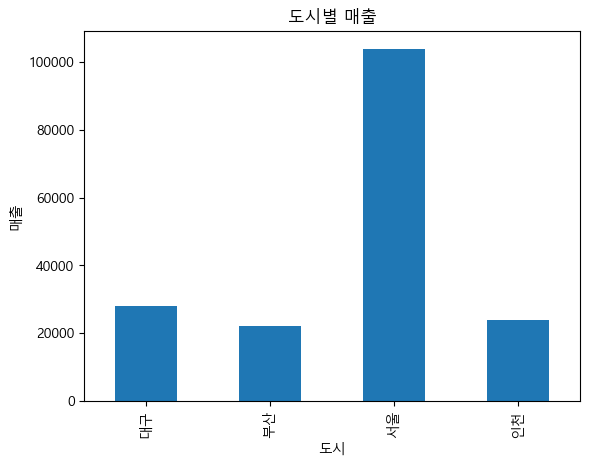

In [31]:
# 1. 한글 폰트 설정 (윈도우 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

city_sales = df.groupby('도시')['주문금액'].sum()

city_sales.plot(kind='bar')

plt.title('도시별 매출')
plt.xlabel('도시')
plt.ylabel('매출')

plt.show()

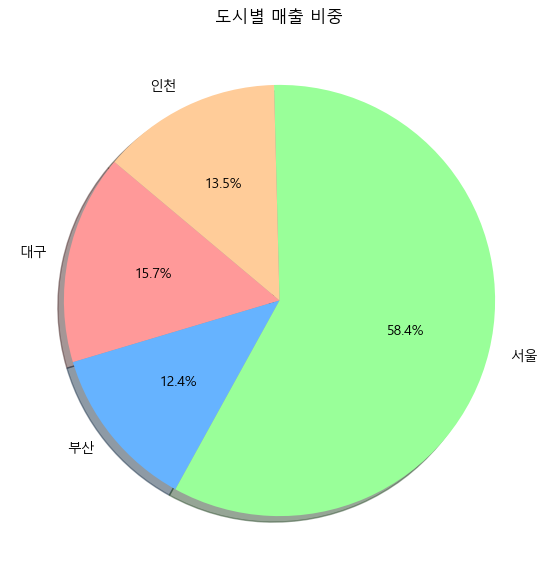

In [30]:
# 2. 데이터 그룹화 (도시별 주문금액 합계)
city_sales = df.groupby('도시')['주문금액'].sum()
# 1. 한글 폰트 설정 (윈도우 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
# 3. 파이 차트 그리기
plt.figure(figsize=(10, 7)) # 그래프 크기 설정
city_sales.plot(
    kind='pie', 
    autopct='%1.1f%%',   # 비율 표시 (소수점 첫째자리까지)
    startangle=140,      # 시작 각도 설정 (보기 좋게 회전)
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], # 색상 테마
    shadow=True          # 그림자 효과
)

plt.title('도시별 매출 비중')
plt.ylabel('') # 불필요한 '주문금액' 라벨 제거
plt.show()

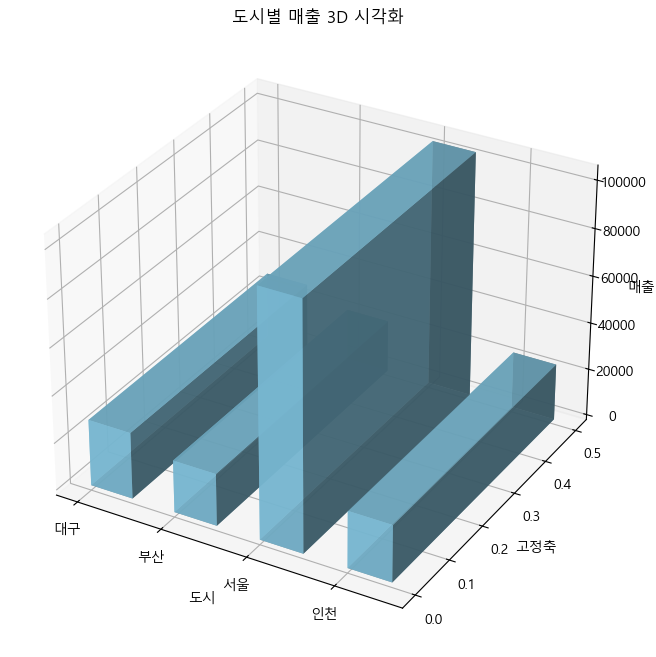

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 한글 및 3D 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') # 3D 축 생성

# 2. 데이터 준비
city_sales = df.groupby('도시')['주문금액'].sum()
cities = city_sales.index
sales = city_sales.values

# 3. 좌표 설정
xpos = np.arange(len(cities)) # 도시 위치 (0, 1, 2...)
ypos = np.zeros(len(cities))  # Y축은 0으로 고정
zpos = np.zeros(len(cities))  # 막대가 시작할 바닥 높이

# 막대의 폭(dx), 깊이(dy), 높이(dz)
dx = 0.5 * np.ones(len(cities))
dy = 0.5 * np.ones(len(cities))
dz = sales # 매출액만큼 높이 설정

# 4. 3D 막대 그리기
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color='skyblue', alpha=0.8)

# 5. 라벨 및 타이틀
ax.set_xticks(xpos)
ax.set_xticklabels(cities)
ax.set_xlabel('도시')
ax.set_ylabel('고정축')
ax.set_zlabel('매출액')
plt.title('도시별 매출 3D 시각화')

plt.show()

In [34]:
! pip install folium


   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]



In [37]:
import folium
import pandas as pd

# 1. 예시 데이터 생성 (사용자님의 df와 연결하시면 됩니다)
data = {
    '도시': ['서울', '부산', '대구', '광주', '대전', '울산', '인천'],
    '주문금액': [15000000, 12000000, 8000000, 5000000, 7000000, 6000000, 9000000]
}
df_sales = pd.DataFrame(data)

# 2. 도시별 위도, 경도 좌표 데이터 (딕셔너리)
geo_data = {
    '서울': [37.5665, 126.9780],
    '부산': [35.1796, 129.0756],
    '대구': [35.8714, 128.6014],
    '광주': [35.1595, 126.8526],
    '대전': [36.3504, 127.3845],
    '울산': [35.5384, 129.3114],
    '인천': [37.4563, 126.7052]
}

# 3. 지도 초기화 (대한민국 중심부 좌표)
m = folium.Map(location=[36.5, 127.5], zoom_start=7, tiles='OpenStreetMap')

# 4. 데이터프레임의 데이터를 순회하며 지도에 표시
for index, row in df_sales.iterrows():
    city = row['도시']
    sales = row['주문금액']
    
    if city in geo_data:
        location = geo_data[city]
        
        # 매출 규모에 따른 원의 크기 설정 (반지름)
        radius = sales / 500000  # 데이터 값에 맞춰 적절히 조절
        
        # 지도에 원형 마커 추가
        folium.CircleMarker(
            location=location,
            radius=radius,
            popup=f"<b>{city}</b><br>매출액: {sales:,}원", # 클릭 시 나타날 팝업
            tooltip=city,                               # 마우스 올릴 시 나타날 툴팁
            color='crimson',                             # 원의 테두리 색상
            fill=True,
            fill_color='crimson',                        # 원의 내부 색상
            fill_opacity=0.6
        ).add_to(m)

# 5. 지도를 HTML 파일로 저장하거나 주피터 노트북에서 바로 표시
m.save('korea_sales_map.html')
m  # 주피터 노트북 환경이라면 지도가 바로 보입니다.

In [38]:
import folium
import pandas as pd

# 1. 데이터 준비
data = {
    '도시': ['서울', '부산', '대구', '광주', '대전'],
    '주문금액': [150, 120, 80, 50, 70] # 단위: 백만 원 (막대 높이 조절용)
}
df_sales = pd.DataFrame(data)

geo_data = {
    '서울': [37.5665, 126.9780],
    '부산': [35.1796, 129.0756],
    '대구': [35.8714, 128.6014],
    '광주': [35.1595, 126.8526],
    '대전': [36.3504, 127.3845]
}

# 2. 지도 초기화
m = folium.Map(location=[36.5, 127.5], zoom_start=7)

# 3. HTML/CSS를 이용한 막대 마커 추가
for index, row in df_sales.iterrows():
    city = row['도시']
    sales = row['주문금액']
    
    if city in geo_data:
        location = geo_data[city]
        
        # HTML로 막대기 모양 만들기 (CSS 활용)
        # height를 매출액(sales)에 비례하게 설정합니다.
        bar_html = f"""
            <div style="
                width: 20px; 
                height: {sales}px; 
                background-color: royalblue; 
                border: 1px solid white;
                opacity: 0.8;
                display: flex;
                align-items: flex-end;
                justify-content: center;
                color: white;
                font-size: 10px;
                font-weight: bold;
                ">
                {sales}
            </div>
            <div style="text-align: center; font-size: 12px; font-weight: bold; width: 20px;">
                {city[:1]}
            </div>
        """
        
        # 지도에 HTML 마커 삽입
        folium.Marker(
            location=location,
            icon=folium.DivIcon(
                icon_size=(20, sales + 20),
                icon_anchor=(10, sales + 10), # 막대 하단이 좌표에 오도록 조정
                html=bar_html
            ),
            popup=f"{city}: {sales}백만원"
        ).add_to(m)

# 4. 결과 저장 및 확인
m.save('korea_bar_map.html')
m

In [39]:
!pip install vincent

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for vincent: filename=vincent-0.4.4-py3-none-any.whl size=35221 sha256=0bf12cabed2200f0e9c7e641408a13e875978a1097c62c3efbf1845370386bbb
  Stored in directory: c:\users\20228\appdata\local\pip\cache\wheels\40\44\53\075cd2390f94759dbcfb727f593e1884b41267f89564bcdfd3
Successfully built vincent


In [40]:
! pip install json

ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json


In [41]:
import folium
import json
import pandas as pd
import vincent

# 1. 샘플 데이터: 각 도시별 상세 매출 데이터 (분기별)
city_detail_data = {
    '서울': [40, 50, 30, 45],
    '부산': [30, 35, 40, 45],
    '대구': [20, 25, 20, 30],
    '광주': [15, 20, 25, 20],
    '대전': [25, 30, 35, 30]
}

# 도시 좌표 정보
geo_data = {
    '서울': [37.5665, 126.9780],
    '부산': [35.1796, 129.0756],
    '대구': [35.8714, 128.6014],
    '광주': [35.1595, 126.8526],
    '대전': [36.3504, 127.3845]
}

# 2. 지도 생성
m = folium.Map(location=[36.5, 127.5], zoom_start=7)

# 3. 도시별 차트 생성 및 툴팁 연결
for city, coords in geo_data.items():
    # Vincent를 사용하여 막대 차트 생성
    chart = vincent.Bar(city_detail_data[city], width=400, height=200)
    chart.axis_titles(x='분기', y='매출')
    
    # 차트 데이터를 JSON으로 변환
    chart_json = json.loads(chart.to_json())
    
    # 툴팁에 들어갈 Vega 차트 설정
    vega_chart = folium.Vega(chart_json, width=450, height=250)
    
    # 마커 생성 (마우스를 올리면 tooltip이 작동)
    marker = folium.Marker(
        location=coords,
        popup=f"{city} 상세 매출 (클릭)",
        tooltip=folium.Tooltip(vega_chart) # 이 부분이 핵심! 차트를 툴팁에 넣음
    )
    
    marker.add_to(m)

# 4. 저장 및 결과 확인
m.save('chart_on_hover.html')
m

C:\Users\20228\AppData\Local\Programs\Python\Python311\Lib\site-packages\vincent\core.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_string
